# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as ctx
import sys
import os

from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import Markdown, display as ipy_display

# Dynamic Path Setup
sys.path.append(os.path.abspath(os.path.join('..')))

from src import config

# Visual Settings
sns.set_style("whitegrid")

# PDF-safe plotting defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100
plt.rcParams["figure.autolayout"] = True

pd.set_option('display.max_columns', None)

def safe_figsize(n_rows, width=11, row_height=2.1, max_height=12):
    return (width, min(max_height, max(4, n_rows * row_height)))

In [2]:
INTERIM_DATA_PATH = '../data/interim/water_quality_mvp_baseline.parquet'
df_interim = pd.read_parquet(INTERIM_DATA_PATH)

print(f"Interim data shape: {df_interim.shape}")

Interim data shape: (9319, 10)


In [8]:
print(df_interim.head())

    Latitude  Longitude Sample Date   swir22      NDMI     MNDWI    pet  \
0 -28.760833  17.730278  2011-01-02   7645.0  0.185538  0.195595  174.2   
1 -26.861111  28.884722  2011-01-03  10574.0  0.124566 -0.180134  124.1   
2 -26.450000  28.085833  2011-01-03  14201.0 -0.083293 -0.252805  127.5   
3 -27.671111  27.236944  2011-01-03  11403.0  0.048048 -0.105416  129.7   
4 -27.356667  27.286389  2011-01-03   9643.0  0.141147 -0.142683  129.2   

   Total Alkalinity  Electrical Conductance  Dissolved Reactive Phosphorus  
0           128.912                   555.0                           10.0  
1            74.720                   162.9                          163.0  
2            89.254                   573.0                           80.0  
3            82.000                   203.6                          101.0  
4            56.100                   145.1                          151.0  


### Train-Test Split

In [3]:
TARGET_COL = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

X = df_interim.drop(columns=TARGET_COL)
y = df_interim[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2, 
    random_state=42,
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape} (Set aside until final evaluation)")

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# For the rest of the notebook, we strictly use df_train
df = df_train.copy()

X_train: (7455, 7), y_train: (7455, 3)
X_test: (1864, 7), y_test: (1864, 3) (Set aside until final evaluation)


### "Bird's Eye" View

In [10]:
# Peek at the data (chunked columns to avoid very wide table output)
chunk_size = 8

# Round all numeric columns to 4 decimals for display only
df_display = df.copy()
num_display_cols = df_display.select_dtypes(include=[np.number]).columns
df_display[num_display_cols] = df_display[num_display_cols].round(4)

for i in range(0, df_display.shape[1], chunk_size):
    cols = df_display.columns[i:i + chunk_size]
    print(f"Preview columns {i+1} to {i + len(cols)}:")
    display(df_display[cols].head())

# Data types and missing values (already vertical, but keep compact)
print("Data types and missing values:")
info_df = pd.DataFrame({
    "Data Type": df_display.dtypes.astype(str),
    "Missing Values": df_display.isnull().sum(),
    "Missing %": (df_display.isnull().sum() / len(df_display) * 100).round(2),
    "Unique Values": df_display.nunique()
}).sort_values(by="Missing %", ascending=False)

display(info_df)

# Baseline statistical summary in chunks (prevents huge horizontal output)
# Chunk 1: columns 1-6
cols_1 = df_display.columns[0:6]
display("Describe columns 1 to 6:")

desc_1 = df_display[cols_1].describe(include="all").T
num_cols_1 = desc_1.select_dtypes(include="number").columns
display(desc_1.style.format({c: "{:.4f}" for c in num_cols_1}))

# Chunk 2: columns 7-12 (only if they exist)
if df_display.shape[1] > 6:
    cols_2 = df_display.columns[6:12]
    print("Describe columns 7 to 12:")
    display(df_display[cols_2].describe(include="all").T.round(4))

# Chunk 3: columns 13-18 (only if they exist)
if df_display.shape[1] > 12:
    cols_3 = df_display.columns[12:18]
    print("Describe columns 13 to 18:")
    display(df_display[cols_3].describe(include="all").T.round(4))

Preview columns 1 to 8:


,Latitude,Longitude,Sample Date,swir22,NDMI,MNDWI,pet,Total Alkalinity
2183,-33.8181,19.6947,2012-05-21,NaN,NaN,NaN,199.7,27.637
6252,-25.5788,29.1275,2014-07-14,13276.5,-0.0733,-0.2285,166.4,27.200
7834,-34.4058,19.6006,2014-03-12,11984.0,0.0106,-0.2135,158.3,88.362
3337,-30.3361,27.3594,2013-01-23,7721.5,0.2085,0.0916,161.5,66.528
6481,-27.0101,26.6981,2014-08-20,10685.5,-0.0436,-0.1225,185.5,153.848


Preview columns 9 to 10:


,Electrical Conductance,Dissolved Reactive Phosphorus
2183,359.9,18.0
6252,349.6,20.0
7834,1339.0,20.0
3337,142.2,10.0
6481,724.0,178.0


Data types and missing values:


,Data Type,Missing Values,Missing %,Unique Values
NDMI,float64,876,11.75,2366
swir22,float64,876,11.75,4193
MNDWI,float64,876,11.75,2382
Latitude,float64,0,0.00,161
Longitude,float64,0,0.00,161
Sample Date,datetime64[ns],0,0.00,1311
pet,float64,0,0.00,863
Total Alkalinity,float64,0,0.00,7084
Electrical Conductance,float64,0,0.00,3381
Dissolved Reactive Phosphorus,float64,0,0.00,211


'Describe columns 1 to 6:'

,count,mean,min,25%,50%,75%,max,std
Latitude,7455.000000,-28.483815,-34.405800,-30.160100,-28.058900,-26.861100,-22.225600,2.745617
Longitude,7455.000000,26.872601,17.730300,26.353100,27.409100,29.245600,32.325000,3.545025
Sample Date,7455,2013-08-07 12:16:42.494969600,2011-01-03 00:00:00,2012-06-09 00:00:00,2013-08-29 00:00:00,2014-10-16 00:00:00,2015-12-31 00:00:00,nan
swir22,6579.000000,11434.858109,3634.000000,9849.250000,11273.000000,12912.500000,28332.500000,2538.229433
NDMI,6579.000000,0.021046,-0.328300,-0.037100,0.021300,0.073500,0.567900,0.077906
MNDWI,6579.000000,-0.144130,-0.300500,-0.211200,-0.167500,-0.103950,0.591000,0.097713


Describe columns 7 to 12:


,count,mean,std,min,25%,50%,75%,max
pet,7455.0,175.2504,29.6257,52.70,156.2000,172.500,193.100,270.800
Total Alkalinity,7455.0,119.0293,74.3948,5.00,55.8465,113.602,169.594,361.676
Electrical Conductance,7455.0,485.5511,341.0354,23.09,208.2000,404.000,691.000,1506.000
Dissolved Reactive Phosphorus,7455.0,43.2369,50.7675,5.00,10.0000,20.000,46.000,195.000


### Target Variable Analysis

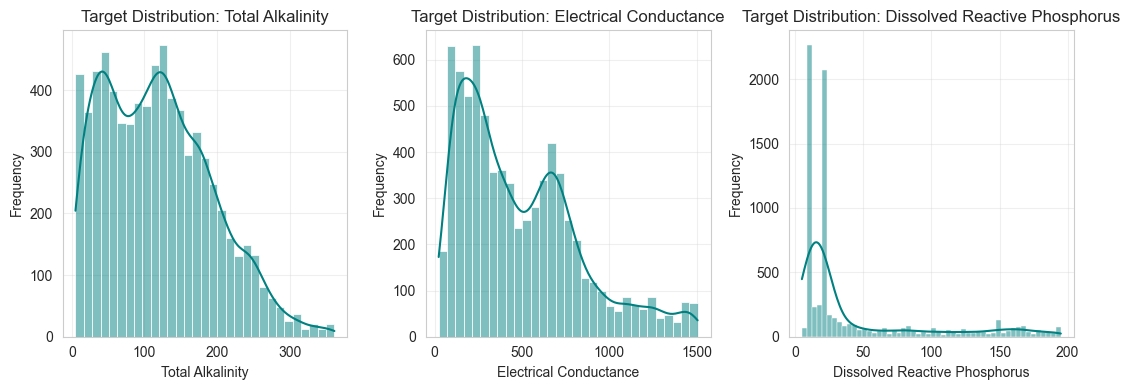

In [11]:
# Separate features by type for programmatic plotting
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_cols = [c for c in num_cols if c not in TARGET_COL]
cat_cols = [c for c in cat_cols if c not in TARGET_COL]

n_targets = len(TARGET_COL)
cols_per_row = 3
n_rows = (n_targets + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
axes = np.array(axes).reshape(-1)  # handle 1-row/1-col safely

for idx, t_col in enumerate(TARGET_COL):
    sns.histplot(df[t_col].dropna(), kde=True, ax=axes[idx], color='teal')
    axes[idx].set_title(f"Target Distribution: {t_col}")
    axes[idx].set_xlabel(t_col)
    axes[idx].set_ylabel("Frequency")
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_targets, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Numeric Feature Distribution

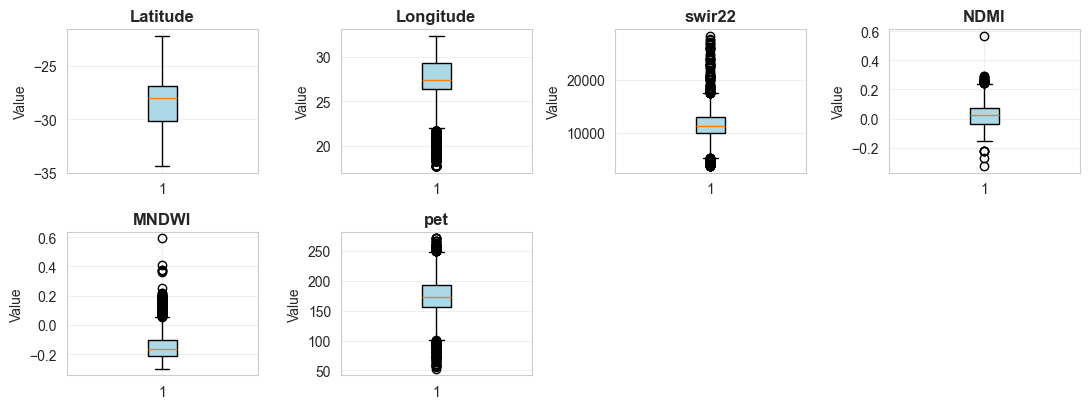

In [12]:
if num_cols:
    cols_per_row = 4
    n_rows = (len(num_cols) + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
    axes = axes.flatten() # Safe because cols_per_row > 1
    
    for idx, col in enumerate(num_cols):
        axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(num_cols), len(axes)):
        axes[idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()

,Feature,Skewness,Kurtosis
6,green,14.283,262.547
7,swir16,1.810,23.531
10,MNDWI,1.339,2.095
3,soil_ph,1.062,2.563
5,nir,1.026,9.756
1,Longitude,-0.940,0.148
8,swir22,0.802,3.918
2,Elevation_m,-0.554,-1.189
0,Latitude,-0.453,-0.284
9,NDMI,0.236,0.074


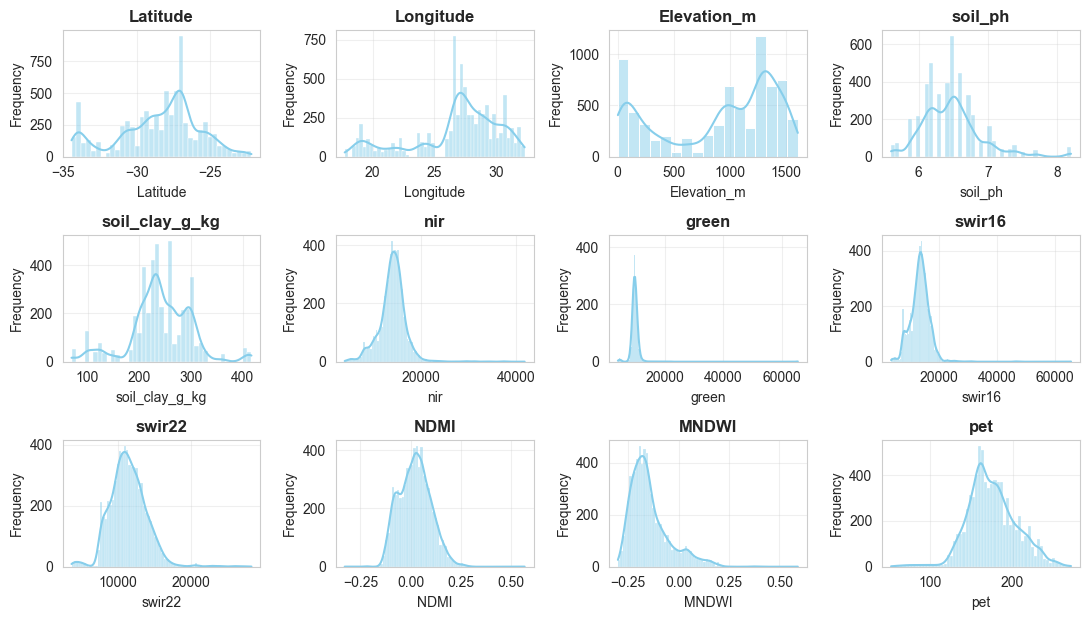

In [18]:
# Skewness and Kurtosis for numeric features
if num_cols:
    dist_stats = []
    for col in num_cols:
        dist_stats.append({
            'Feature': col,
            'Skewness': round(skew(df[col].dropna()), 3),
            'Kurtosis': round(kurtosis(df[col].dropna()), 3)
        })
    
    dist_df = pd.DataFrame(dist_stats)
    display(dist_df.sort_values(by='Skewness', key=abs, ascending=False))
    
    # Histogram + KDE plots for numeric features
    cols_per_row = 4
    n_rows = (len(num_cols) + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(num_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(num_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns for distribution analysis.")

### Categorical Feature Distribution

In [15]:
# if cat_cols:
#     cols_per_row = 3
#     n_rows = (len(cat_cols) + cols_per_row - 1) // cols_per_row
    
#     fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
#     axes = axes.flatten()
    
#     MAX_CATEGORIES = 15 # Safety valve for high-cardinality columns
    
#     for idx, col in enumerate(cat_cols):
#         value_counts = df[col].value_counts()
        
#         # Apply safety valve
#         if len(value_counts) > MAX_CATEGORIES:
#             top_counts = value_counts.iloc[:MAX_CATEGORIES]
#             other_count = pd.Series({'...Others': value_counts.iloc[MAX_CATEGORIES:].sum()})
#             value_counts = pd.concat([top_counts, other_count])
            
#         axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue')
#         axes[idx].set_xticks(range(len(value_counts)))
#         axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
#         axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
#         axes[idx].set_ylabel('Count')
#         axes[idx].grid(True, alpha=0.3)
    
#     # Hide empty subplots
#     for idx in range(len(cat_cols), len(axes)):
#         axes[idx].set_visible(False)
        
#     plt.tight_layout()
#     plt.show()

### Correlation Matrix

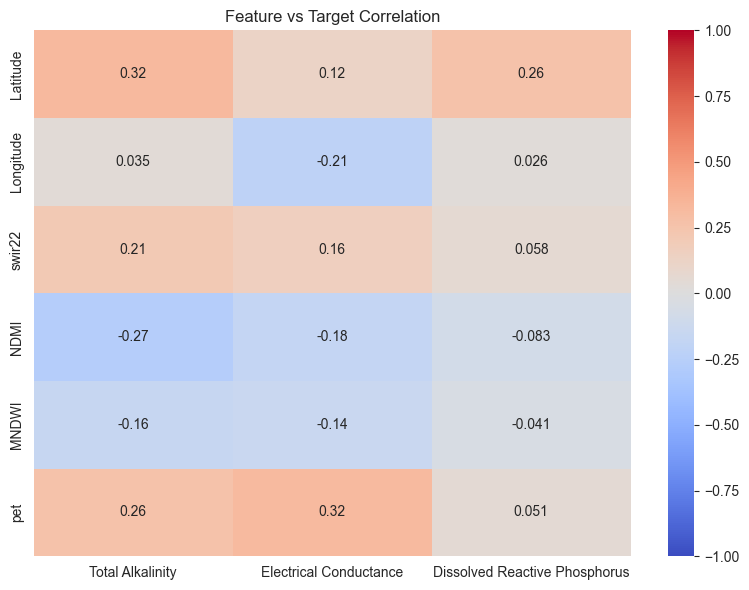

In [16]:
# Feature-to-target correlation only
feature_target_corr = df[num_cols + TARGET_COL].corr().loc[num_cols, TARGET_COL]

plt.figure(figsize=(8, max(6, len(num_cols) * 0.25)))
sns.heatmap(feature_target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Feature vs Target Correlation")
plt.tight_layout()
plt.show()

### Missing Data Patterns

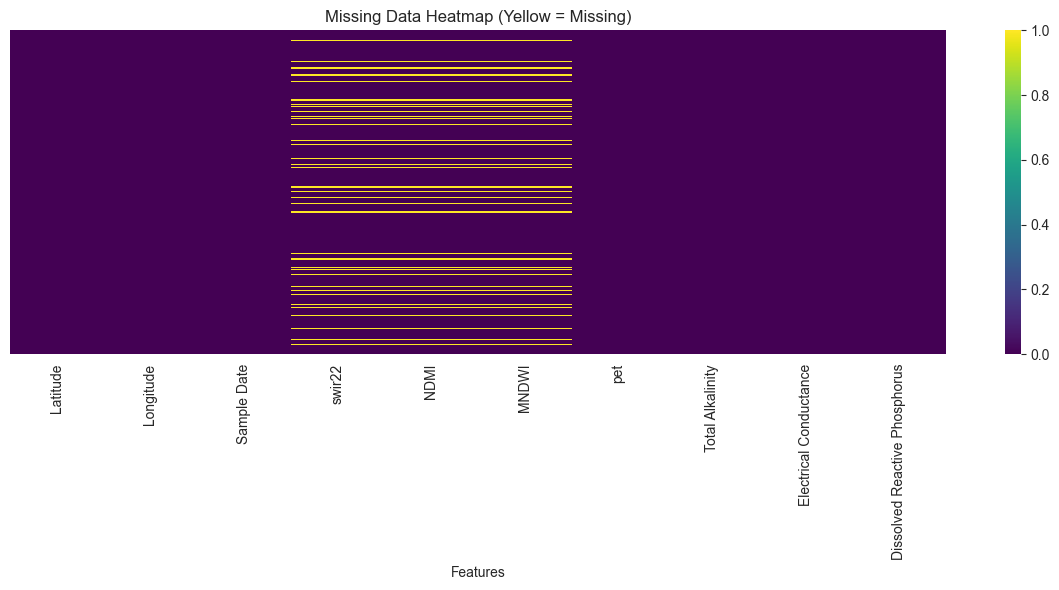

In [17]:
# Missing value heatmap
missing_data = df.isnull()

if missing_data.any().any():
    plt.figure(figsize=(12, 6))
    sns.heatmap(missing_data, cbar=True, cmap='viridis', yticklabels=False)
    plt.title("Missing Data Heatmap (Yellow = Missing)")
    plt.xlabel("Features")
    plt.tight_layout()
    plt.show()
    
    # Missing data correlation
    if missing_data.sum().sum() > 0:
        missing_corr = missing_data.corr().round(2)

        # Only show if there's meaningful correlation between missing values
        if (missing_corr.abs() > 0.5).sum().sum() > len(missing_corr):
            plt.figure(figsize=(10, 8))
            sns.heatmap(
                missing_corr,
                annot=True,
                fmt=".2f",
                cmap='coolwarm',
                vmin=-1,
                vmax=1,
                center=0
            )
            plt.title("Missing Data Correlation (Do missing values occur together?)")
            plt.tight_layout()
            plt.show()
else:
    print("✓ No missing data detected in the training set.")

### Target Relationship Analysis

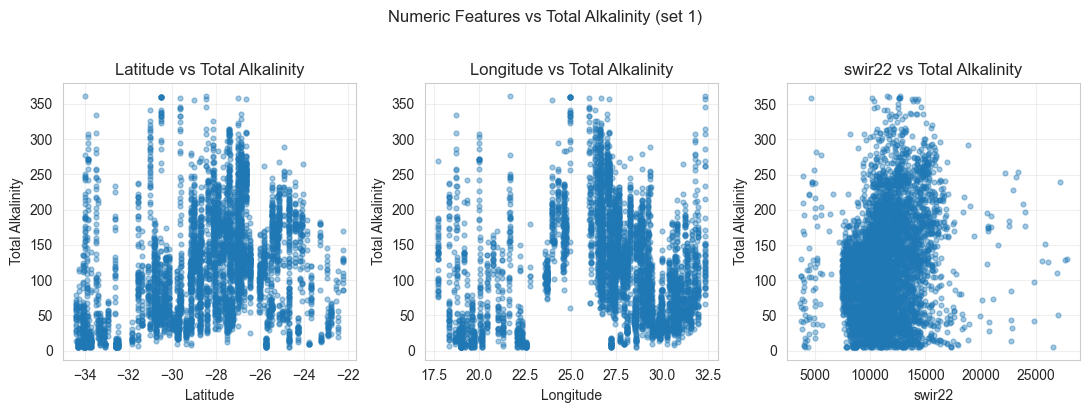

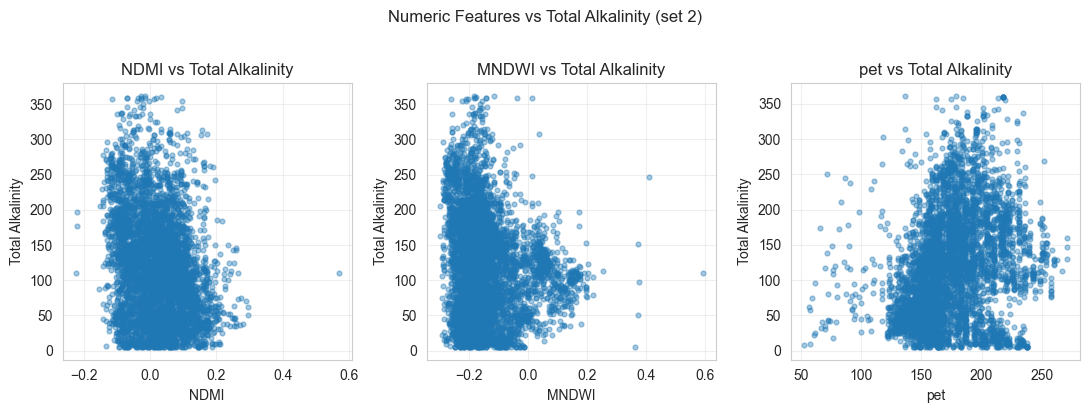

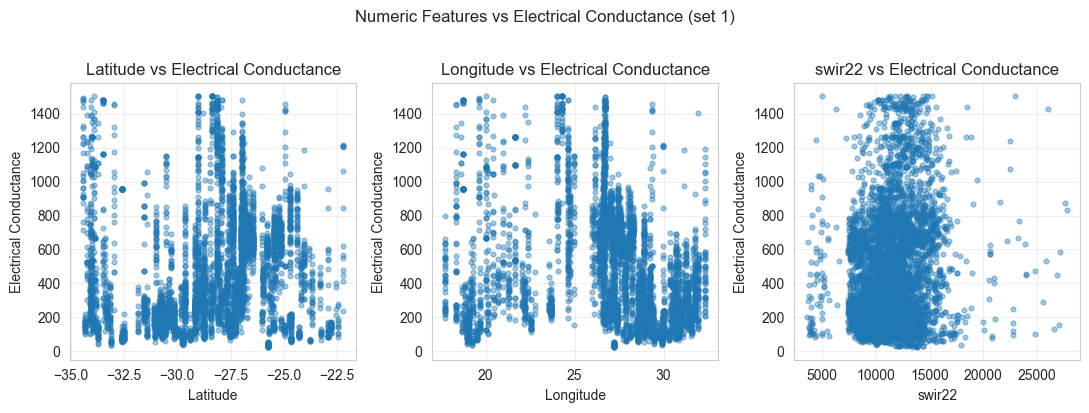

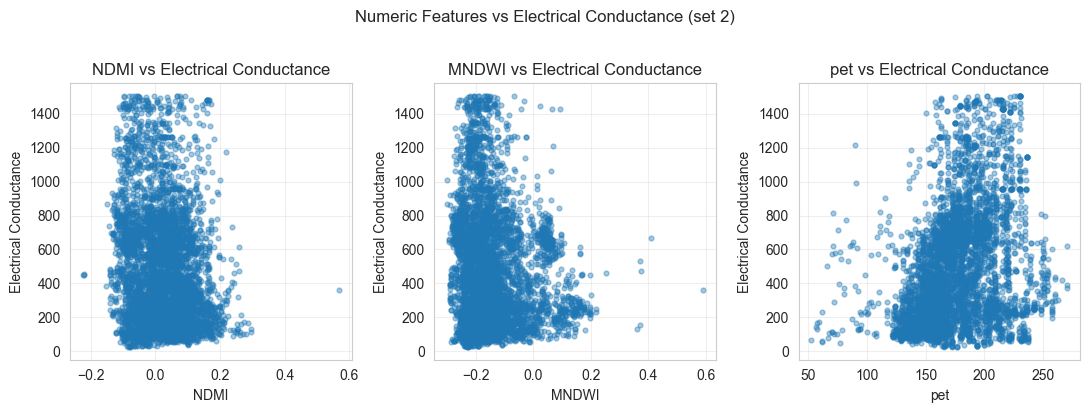

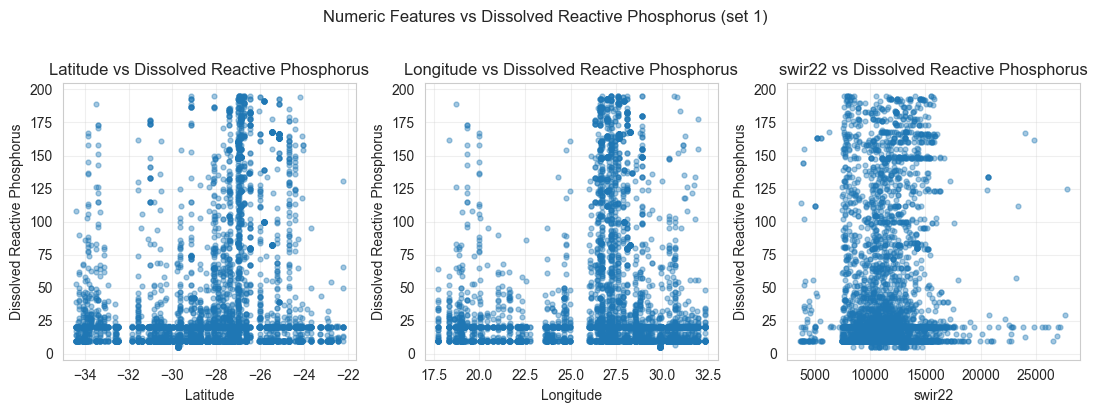

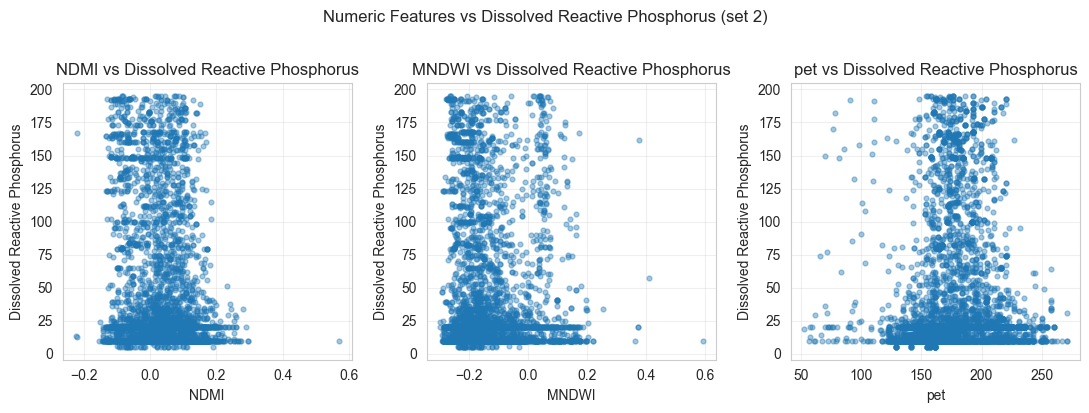

In [18]:
# Numeric Features vs Target
if num_cols and TARGET_COL:
    cols_per_row = 3
    plots_per_figure = 3

    for t_col in TARGET_COL:
        # chunk numeric columns so each target gets multiple small figures
        for start in range(0, len(num_cols), plots_per_figure):
            chunk_cols = num_cols[start:start + plots_per_figure]
            n_plots = len(chunk_cols)
            n_rows = (n_plots + cols_per_row - 1) // cols_per_row

            fig, axes = plt.subplots(
                n_rows,
                cols_per_row,
                figsize=safe_figsize(n_rows, width=11, row_height=2.4, max_height=10)
            )
            axes = np.array(axes).reshape(-1)

            for idx, col in enumerate(chunk_cols):
                ax = axes[idx]

                plot_df = df[[col, t_col]].dropna()
                if len(plot_df) > 5000:
                    plot_df = plot_df.sample(5000, random_state=42)

                ax.scatter(plot_df[col], plot_df[t_col], alpha=0.4, s=12)
                ax.set_xlabel(col)
                ax.set_ylabel(t_col)
                ax.set_title(f"{col} vs {t_col}")
                ax.grid(True, alpha=0.3)

            for idx in range(n_plots, len(axes)):
                axes[idx].set_visible(False)

            fig.suptitle(
                f"Numeric Features vs {t_col} "
                f"(set {start // plots_per_figure + 1})",
                y=1.02
            )
            plt.tight_layout()
            plt.show()
else:
    print("No numeric features or target columns available for regression relationship plots.")

### Outlier Detection (IQR Method)

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
1,Longitude,996,13.36,22.01,33.58
4,MNDWI,346,4.64,-0.37,0.06
2,swir22,166,2.23,5254.38,17507.38
5,pet,162,2.17,100.85,248.45
3,NDMI,34,0.46,-0.20,0.24
0,Latitude,0,0.00,-35.11,-21.91


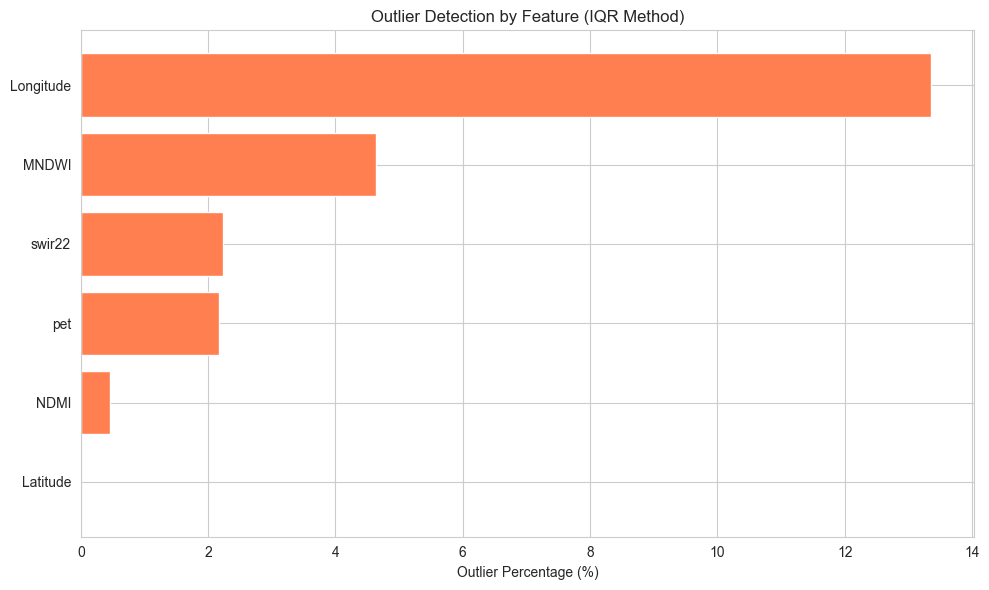

In [19]:
# Identify outliers using IQR method
if num_cols:
    outlier_summary = []
    
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100
        
        outlier_summary.append({
            'Feature': col,
            'Outlier Count': outlier_count,
            'Outlier %': round(outlier_pct, 2),
            'Lower Bound': round(lower_bound, 2),
            'Upper Bound': round(upper_bound, 2)
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier %', ascending=False)
    display(outlier_df)
    
    # Visualize outlier percentage
    if outlier_df['Outlier %'].sum() > 0:
        plt.figure(figsize=(10, 6))
        plt.barh(outlier_df['Feature'], outlier_df['Outlier %'], color='coral')
        plt.xlabel('Outlier Percentage (%)')
        plt.title('Outlier Detection by Feature (IQR Method)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("No numeric columns to check for outliers.")

### Temporal Analysis (If Applicable)

Using date column: Sample Date
Date range: 2011-01-03 to 2015-12-31


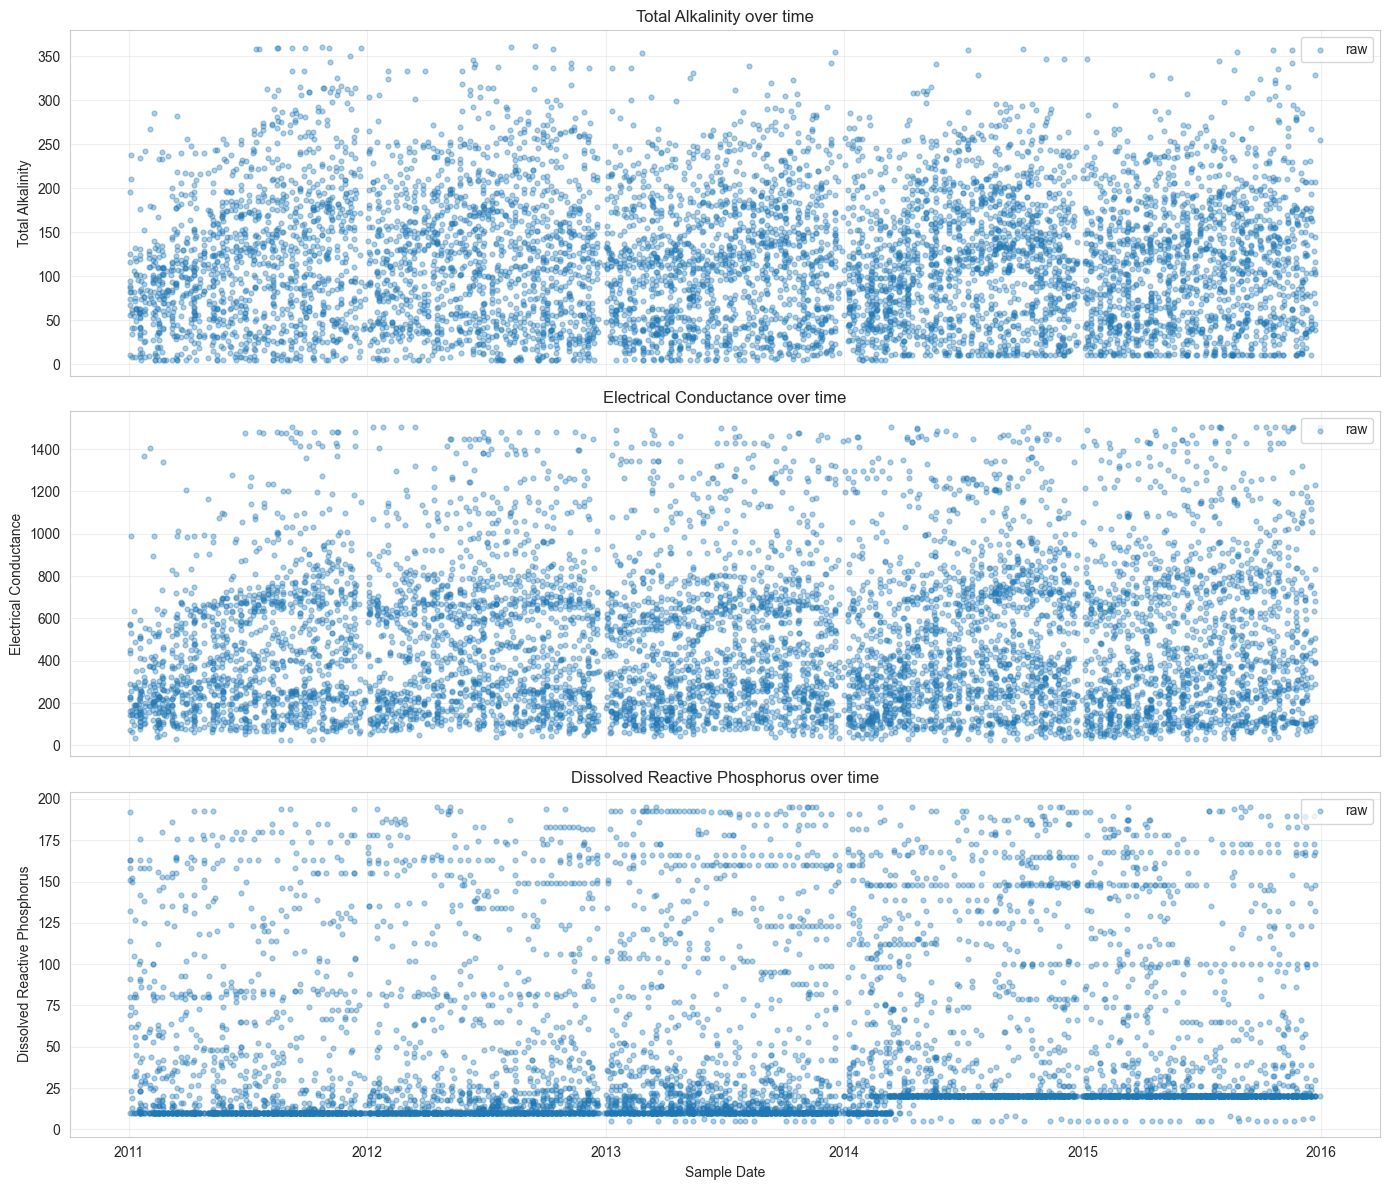

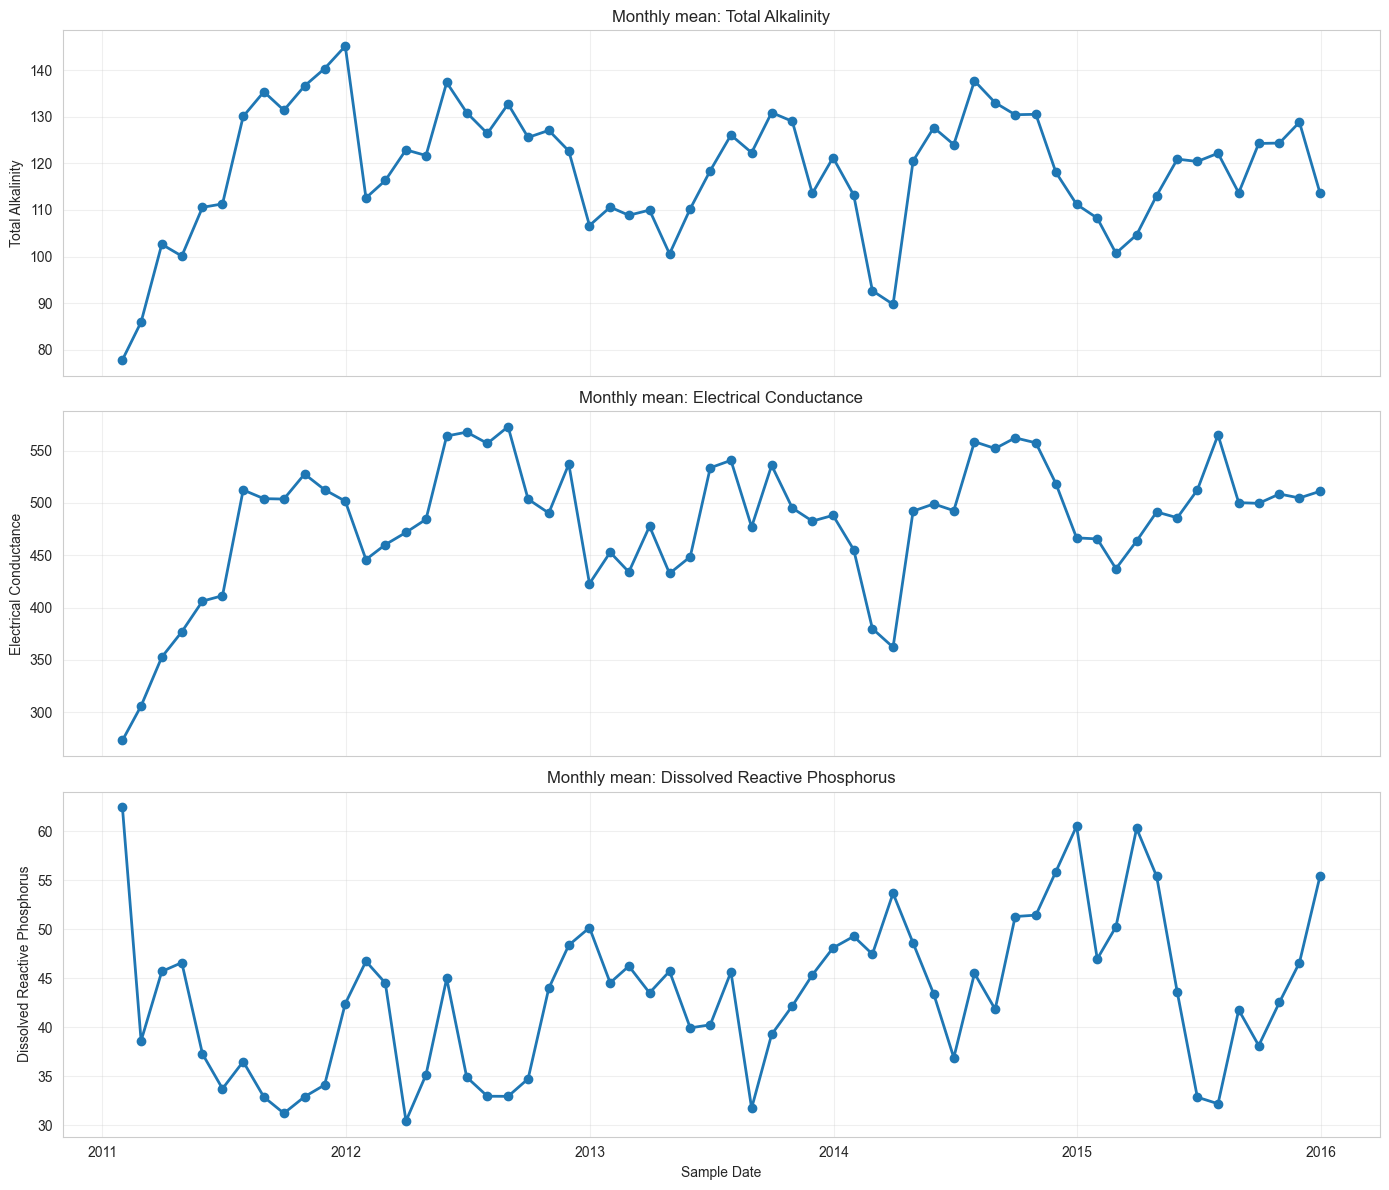

In [20]:
# Temporal analysis for multi-target regression
DATE_COL = "Sample Date"

if DATE_COL in df.columns:
    # Safe datetime parse
    df_time = df.copy()
    df_time[DATE_COL] = pd.to_datetime(df_time[DATE_COL], errors="coerce", dayfirst=True)

    # Drop rows where date failed to parse
    df_time = df_time.dropna(subset=[DATE_COL]).sort_values(DATE_COL)

    if len(df_time) == 0:
        print(f"No valid datetime values found in '{DATE_COL}'.")
    else:
        print(f"Using date column: {DATE_COL}")
        print(f"Date range: {df_time[DATE_COL].min().date()} to {df_time[DATE_COL].max().date()}")

        # 1) Raw scatter per target over time
        n_targets = len(TARGET_COL)
        fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
        axes = np.array(axes).reshape(-1)

        for i, t_col in enumerate(TARGET_COL):
            plot_df = df_time[[DATE_COL, t_col]].dropna()
            axes[i].scatter(plot_df[DATE_COL], plot_df[t_col], alpha=0.35, s=12, label="raw")
            axes[i].set_title(f"{t_col} over time")
            axes[i].set_ylabel(t_col)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend(loc="upper right")

        axes[-1].set_xlabel(DATE_COL)
        plt.tight_layout()
        plt.show()

        # 2) Monthly trend per target (mean)
        monthly = (
            df_time.set_index(DATE_COL)[TARGET_COL]
            .resample("ME")
            .mean()
            .dropna(how="all")
        )

        if not monthly.empty:
            fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
            axes = np.array(axes).reshape(-1)

            for i, t_col in enumerate(TARGET_COL):
                axes[i].plot(monthly.index, monthly[t_col], marker="o", linewidth=2)
                axes[i].set_title(f"Monthly mean: {t_col}")
                axes[i].set_ylabel(t_col)
                axes[i].grid(True, alpha=0.3)

            axes[-1].set_xlabel(DATE_COL)
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough data to compute monthly trends.")
else:
    print("No temporal features detected. Set DATE_COL to your date column name.")

### Cardinality Check

In [ ]:
# # Identify high-cardinality categorical features
# if cat_cols:
#     cardinality_info = []
    
#     for col in cat_cols:
#         unique_count = df[col].nunique()
#         cardinality_pct = (unique_count / len(df)) * 100
        
#         cardinality_info.append({
#             'Feature': col,
#             'Unique Values': unique_count,
#             'Cardinality %': round(cardinality_pct, 2),
#             'Type': 'High' if unique_count > 50 else ('Medium' if unique_count > 10 else 'Low')
#         })
    
#     cardinality_df = pd.DataFrame(cardinality_info).sort_values(by='Unique Values', ascending=False)
#     display(cardinality_df)
    
#     # Flag high-cardinality features that may need special encoding
#     high_card_features = cardinality_df[cardinality_df['Type'] == 'High']['Feature'].tolist()
#     if high_card_features:
#         print(f"\n⚠️ High-cardinality features detected: {high_card_features}")
#         print("   Consider: Target encoding, frequency encoding, or feature hashing.")
# else:
#     print("No categorical columns to check for cardinality.")

### Class Imbalance Analysis

In [ ]:
# # Check for class imbalance (for classification tasks)
# if df[TARGET_COL].dtype == 'object' or df[TARGET_COL].nunique() < 20:
#     value_counts = df[TARGET_COL].value_counts()
#     value_pcts = df[TARGET_COL].value_counts(normalize=True) * 100
    
#     imbalance_df = pd.DataFrame({
#         'Class': value_counts.index,
#         'Count': value_counts.values,
#         'Percentage': [f"{pct:.2f}%" for pct in value_pcts.values]
#     })
    
#     print("Class Distribution:")
#     display(imbalance_df)
    
#     # Calculate imbalance ratio
#     if len(value_counts) == 2:
#         imbalance_ratio = value_counts.max() / value_counts.min()
#         print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
        
#         if imbalance_ratio > 3:
#             print("⚠️ Significant class imbalance detected!")
#             print("   Consider: SMOTE, class weights, or stratified sampling.")
    
#     # Visualization
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # Count plot
#     axes[0].bar(range(len(value_counts)), value_counts.values, color='steelblue')
#     axes[0].set_xticks(range(len(value_counts)))
#     axes[0].set_xticklabels(value_counts.index, rotation=45)
#     axes[0].set_title('Class Distribution (Count)')
#     axes[0].set_ylabel('Count')
#     axes[0].grid(True, alpha=0.3)
    
#     # Pie chart
#     axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
#     axes[1].set_title('Class Distribution (Percentage)')
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Target variable is continuous (regression task). Class imbalance analysis not applicable.")

### Multicollinearity Check

In [21]:
# VIF (Variance Inflation Factor) Analysis
if len(num_cols) > 1:
    # Prepare data for VIF (drop NaNs)
    vif_data = df[num_cols].dropna()
    
    if len(vif_data) > 0 and vif_data.shape[1] > 1:
        vif_values = []
        
        for i, col in enumerate(vif_data.columns):
            try:
                vif = variance_inflation_factor(vif_data.values, i)
                vif_values.append({
                    'Feature': col,
                    'VIF': round(vif, 2)
                })
            except:
                vif_values.append({
                    'Feature': col,
                    'VIF': 'Error'
                })
        
        vif_df = pd.DataFrame(vif_values).sort_values(by='VIF', ascending=False, key=lambda x: pd.to_numeric(x, errors='coerce'))
        display(vif_df)
        
        print("\n💡 VIF Interpretation:")
        print("   VIF < 5: Low multicollinearity")
        print("   VIF 5-10: Moderate multicollinearity")
        print("   VIF > 10: High multicollinearity (consider removing)")
    
    # High correlation pairs
    print("\n" + "="*50)
    print("High Correlation Pairs (|r| > 0.8):")
    print("="*50)
    
    corr_matrix = df[num_cols].corr()
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.8:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': round(corr_val, 3)
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', key=abs, ascending=False)
        display(high_corr_df)
        print("\n⚠️ Consider removing one feature from each highly correlated pair.")
    else:
        print("✓ No highly correlated feature pairs detected (|r| > 0.8).")
else:
    print("Not enough numeric columns for multicollinearity analysis.")

,Feature,VIF
0,Latitude,64.30
2,swir22,44.93
5,pet,35.55
1,Longitude,31.18
4,MNDWI,5.75
3,NDMI,2.04



💡 VIF Interpretation:
   VIF < 5: Low multicollinearity
   VIF 5-10: Moderate multicollinearity
   VIF > 10: High multicollinearity (consider removing)

High Correlation Pairs (|r| > 0.8):
✓ No highly correlated feature pairs detected (|r| > 0.8).


### Geography Visualization

Latitude range: -34.4058 to -22.2256
Longitude range: 17.7303 to 32.3250
Date range: 2011-01-03 to 2015-12-31
Total sample points: 7455


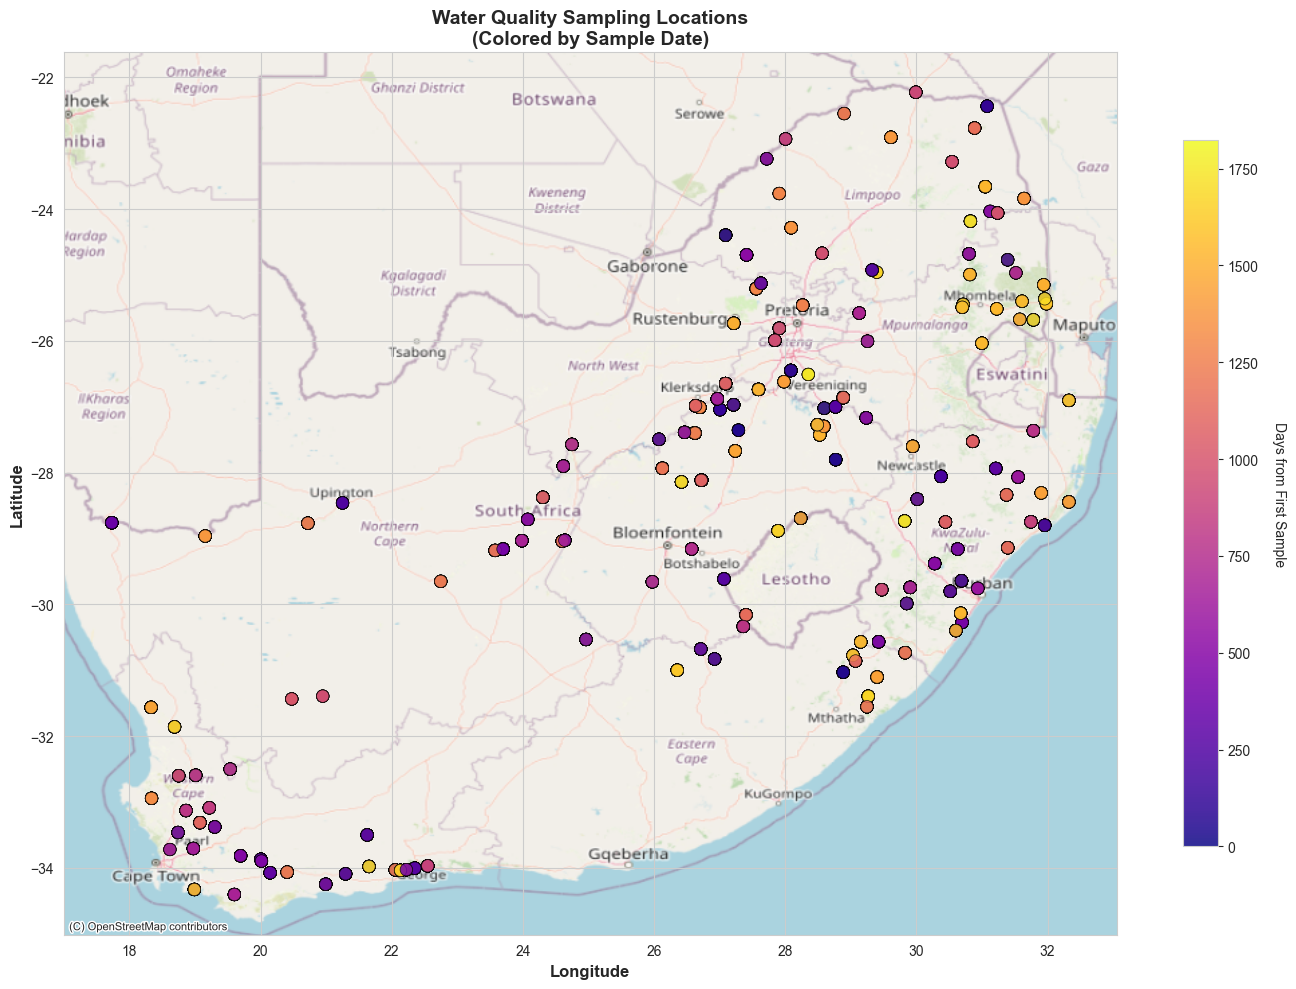

In [22]:
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    
    df_geo = df[['Latitude', 'Longitude', 'Sample Date']].copy()
    df_geo = df_geo.dropna()
    
    df_geo['Sample Date'] = pd.to_datetime(df_geo['Sample Date'], errors='coerce', dayfirst=True)
    df_geo = df_geo.dropna(subset=['Sample Date'])
    
    # Convert dates to numeric for coloring
    date_numeric = (df_geo['Sample Date'] - df_geo['Sample Date'].min()).dt.days
    
    # Bounding box with padding
    lat_min, lat_max = df_geo['Latitude'].min(), df_geo['Latitude'].max()
    lon_min, lon_max = df_geo['Longitude'].min(), df_geo['Longitude'].max()
    lat_pad = (lat_max - lat_min) * 0.05
    lon_pad = (lon_max - lon_min) * 0.05
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Scatter plot colored by date
    scatter = ax.scatter(
        df_geo['Longitude'], 
        df_geo['Latitude'], 
        c=date_numeric, 
        cmap='plasma', 
        alpha=0.85, 
        s=80,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )
    
    # Crop to data extent
    ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
    ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
    
    # Add static map tiles (must come after setting xlim/ylim)
    ctx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto'
    )
    
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title('Water Quality Sampling Locations\n(Colored by Sample Date)', fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Days from First Sample', rotation=270, labelpad=20)
    
    print(f"Latitude range: {lat_min:.4f} to {lat_max:.4f}")
    print(f"Longitude range: {lon_min:.4f} to {lon_max:.4f}")
    print(f"Date range: {df_geo['Sample Date'].min().date()} to {df_geo['Sample Date'].max().date()}")
    print(f"Total sample points: {len(df_geo)}")
    
    plt.tight_layout()
    plt.show()

### Inspecting Validation File

In [4]:
VALIDATION_DATA_PATH = '../data/interim/water_quality_mvp_validation.parquet'
df_validation = pd.read_parquet(VALIDATION_DATA_PATH)

print(f"Validation data shape: {df_validation.shape}")
print("\n" + "="*70)
print("VALIDATION SET - BIRD'S EYE VIEW")
print("="*70 + "\n")

# Peek at the data (chunked columns)
chunk_size = 8

df_val_display = df_validation.copy()
num_val_cols = df_val_display.select_dtypes(include=[np.number]).columns
df_val_display[num_val_cols] = df_val_display[num_val_cols].round(4)

for i in range(0, df_val_display.shape[1], chunk_size):
    cols = df_val_display.columns[i:i + chunk_size]
    print(f"Preview columns {i+1} to {i + len(cols)}:")
    display(df_val_display[cols].head())

# Data types and missing values
print("Data types and missing values:")
val_info_df = pd.DataFrame({
    "Data Type": df_val_display.dtypes.astype(str),
    "Missing Values": df_val_display.isnull().sum(),
    "Missing %": (df_val_display.isnull().sum() / len(df_val_display) * 100).round(2),
    "Unique Values": df_val_display.nunique()
}).sort_values(by="Missing %", ascending=False)

display(val_info_df)

# Statistical summary in chunks
cols_1 = df_val_display.columns[0:6]
print("Describe columns 1 to 6:")
desc_1 = df_val_display[cols_1].describe(include="all").T
num_cols_1 = desc_1.select_dtypes(include="number").columns
display(desc_1.style.format({c: "{:.4f}" for c in num_cols_1}))

if df_val_display.shape[1] > 6:
    cols_2 = df_val_display.columns[6:12]
    print("Describe columns 7 to 12:")
    display(df_val_display[cols_2].describe(include="all").T.round(4))

if df_val_display.shape[1] > 12:
    cols_3 = df_val_display.columns[12:18]
    print("Describe columns 13 to 18:")
    display(df_val_display[cols_3].describe(include="all").T.round(4))


Validation data shape: (200, 10)

VALIDATION SET - BIRD'S EYE VIEW

Preview columns 1 to 8:


,Latitude,Longitude,Sample Date,swir22,NDMI,MNDWI,pet,Total Alkalinity
0,-32.0433,27.8228,2014-09-01,12421.0,0.0144,-0.0697,161.9,NaN
1,-33.3292,26.0775,2015-09-16,NaN,NaN,NaN,177.6,NaN
2,-32.9916,27.6400,2015-05-07,9958.0,0.1281,-0.1480,158.4,NaN
3,-34.0964,24.4392,2012-02-07,NaN,NaN,NaN,130.0,NaN
4,-32.0006,28.5817,2014-10-01,8711.0,-0.0178,0.0801,152.5,NaN


Preview columns 9 to 10:


,Electrical Conductance,Dissolved Reactive Phosphorus
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


Data types and missing values:


,Data Type,Missing Values,Missing %,Unique Values
Dissolved Reactive Phosphorus,float64,200,100.0,0
Electrical Conductance,float64,200,100.0,0
Total Alkalinity,float64,200,100.0,0
MNDWI,float64,19,9.5,151
NDMI,float64,19,9.5,155
swir22,float64,19,9.5,157
Longitude,float64,0,0.0,24
Latitude,float64,0,0.0,24
Sample Date,datetime64[ns],0,0.0,159
pet,float64,0,0.0,86


Describe columns 1 to 6:


,count,mean,min,25%,50%,75%,max,std
Latitude,200.000000,-32.816735,-34.096400,-33.185400,-32.991600,-32.086400,-31.903100,0.652010
Longitude,200.000000,26.583128,24.196400,25.430000,27.366700,27.640000,28.581700,1.322306
Sample Date,200,2013-10-12 01:48:00,2011-01-14 00:00:00,2012-11-07 12:00:00,2014-02-01 12:00:00,2014-10-27 12:00:00,2015-12-28 00:00:00,nan
swir22,181.000000,10297.088398,4286.500000,9157.500000,9973.000000,11138.500000,16452.000000,1702.497464
NDMI,181.000000,0.079475,-0.124600,0.029900,0.081400,0.131200,0.233800,0.071918
MNDWI,181.000000,-0.120030,-0.237200,-0.156600,-0.130600,-0.102400,0.139700,0.067556


Describe columns 7 to 12:


,count,mean,std,min,25%,50%,75%,max
pet,200.0,160.278,25.3465,60.5,140.75,158.4,173.7,218.2
Total Alkalinity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Electrical Conductance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dissolved Reactive Phosphorus,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



VALIDATION SET - GEOGRAPHY VISUALIZATION

Latitude range: -34.0964 to -31.9031
Longitude range: 24.1964 to 28.5817
Date range: 2011-01-14 to 2015-12-28
Total sample points: 200


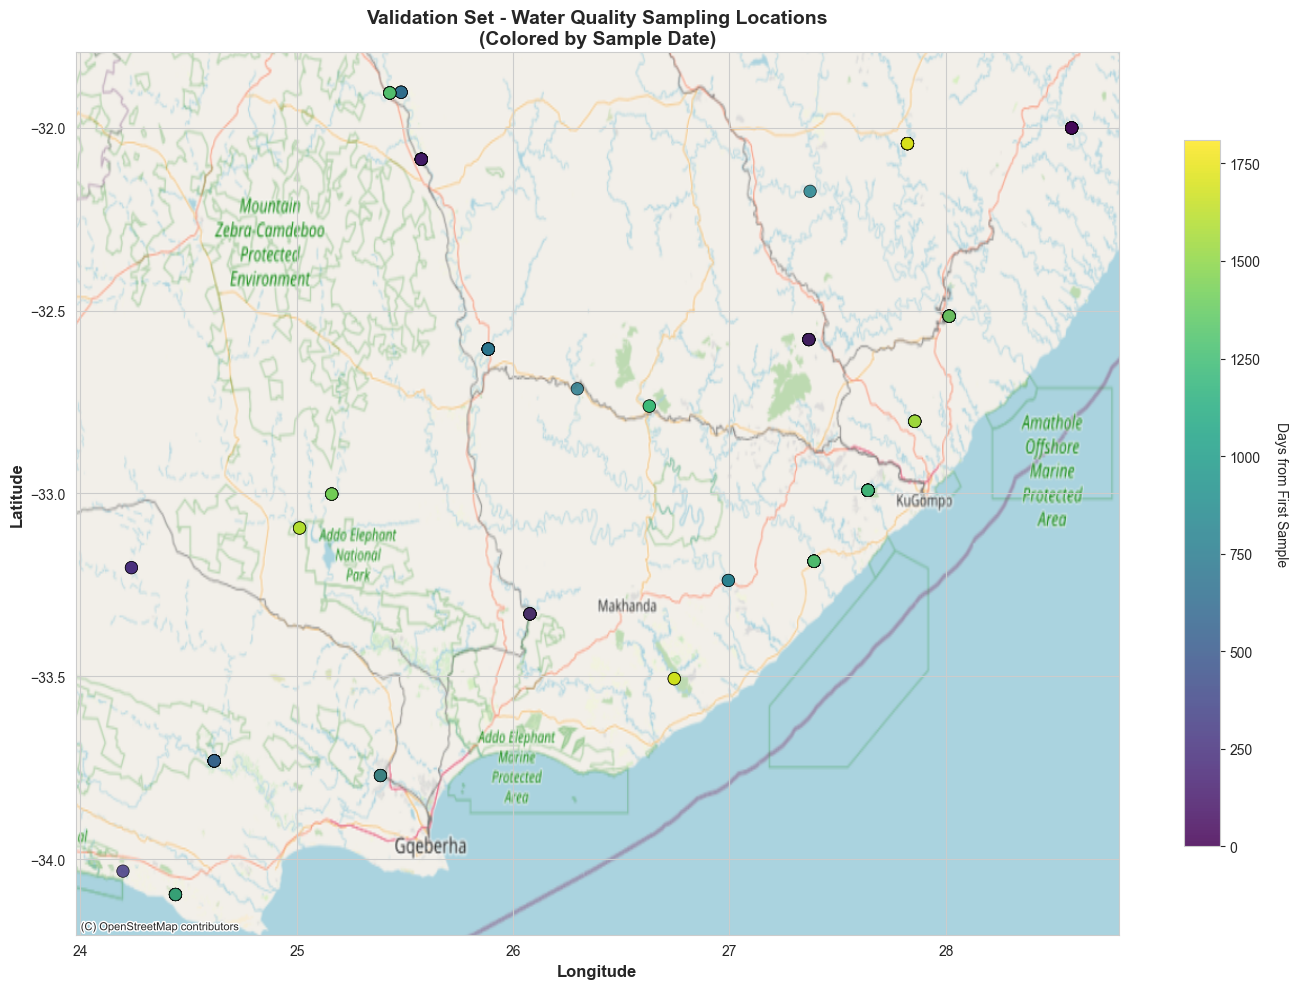

In [5]:
# Geography Visualization
print("\n" + "="*70)
print("VALIDATION SET - GEOGRAPHY VISUALIZATION")
print("="*70 + "\n")

if 'Latitude' in df_validation.columns and 'Longitude' in df_validation.columns:
    
    df_val_geo = df_validation[['Latitude', 'Longitude', 'Sample Date']].copy()
    df_val_geo = df_val_geo.dropna()
    
    df_val_geo['Sample Date'] = pd.to_datetime(df_val_geo['Sample Date'], errors='coerce', dayfirst=True)
    df_val_geo = df_val_geo.dropna(subset=['Sample Date'])
    
    # Convert dates to numeric for coloring
    date_numeric = (df_val_geo['Sample Date'] - df_val_geo['Sample Date'].min()).dt.days
    
    # Bounding box with padding
    lat_min, lat_max = df_val_geo['Latitude'].min(), df_val_geo['Latitude'].max()
    lon_min, lon_max = df_val_geo['Longitude'].min(), df_val_geo['Longitude'].max()
    lat_pad = (lat_max - lat_min) * 0.05
    lon_pad = (lon_max - lon_min) * 0.05
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Scatter plot colored by date
    scatter = ax.scatter(
        df_val_geo['Longitude'], 
        df_val_geo['Latitude'], 
        c=date_numeric, 
        cmap='viridis',  # Different color scheme to distinguish from training
        alpha=0.85, 
        s=80,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )
    
    # Crop to data extent
    ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
    ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
    
    # Add static map tiles
    ctx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto'
    )
    
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title('Validation Set - Water Quality Sampling Locations\n(Colored by Sample Date)', 
                 fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Days from First Sample', rotation=270, labelpad=20)
    
    print(f"Latitude range: {lat_min:.4f} to {lat_max:.4f}")
    print(f"Longitude range: {lon_min:.4f} to {lon_max:.4f}")
    print(f"Date range: {df_val_geo['Sample Date'].min().date()} to {df_val_geo['Sample Date'].max().date()}")
    print(f"Total sample points: {len(df_val_geo)}")
    
    plt.tight_layout()
    plt.show()
else:
    print("Latitude/Longitude columns not found in validation set.")

### Train vs Valid Data


TRAIN vs VALID COMPARISON (Latitude, Longitude, Sample Date)



,dataset,rows,lat_min,lat_max,lat_mean,lon_min,lon_max,lon_mean,date_min,date_max
0,train,7455,-34.405833,-22.225556,-28.483813,17.730278,32.325000,26.872603,2011-01-03,2015-12-31
1,valid,200,-34.096389,-31.903056,-32.816731,24.196389,28.581667,26.583118,2011-01-14,2015-12-28


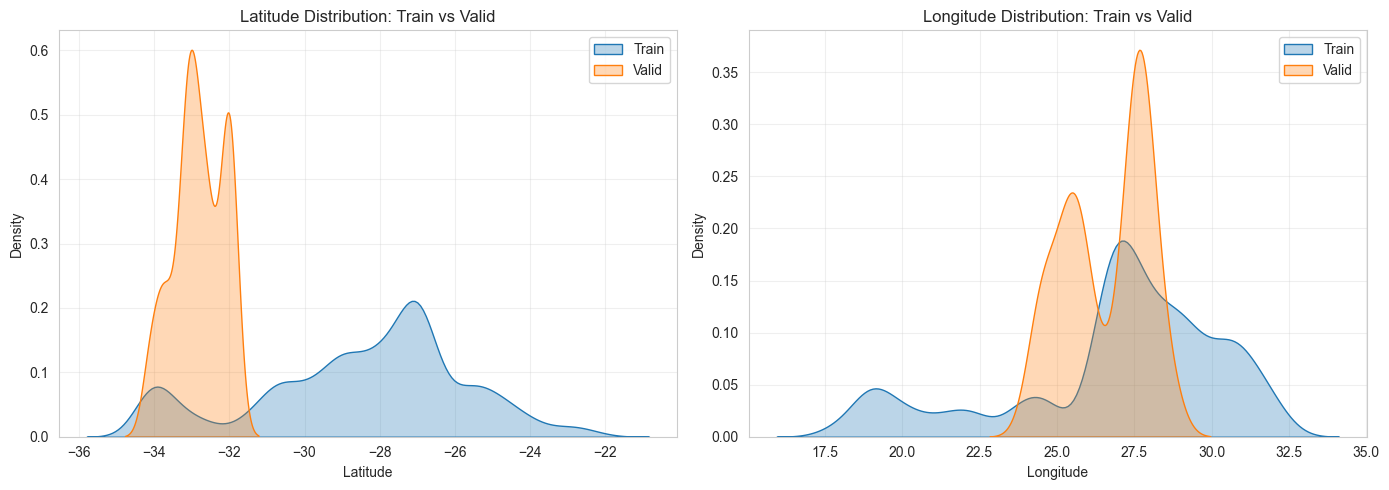

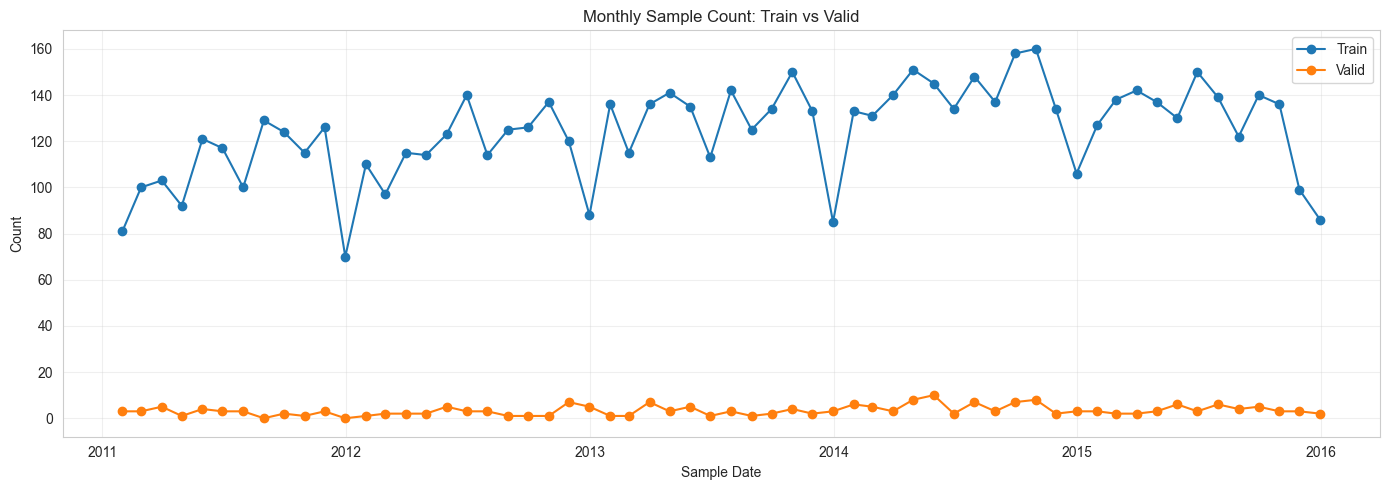

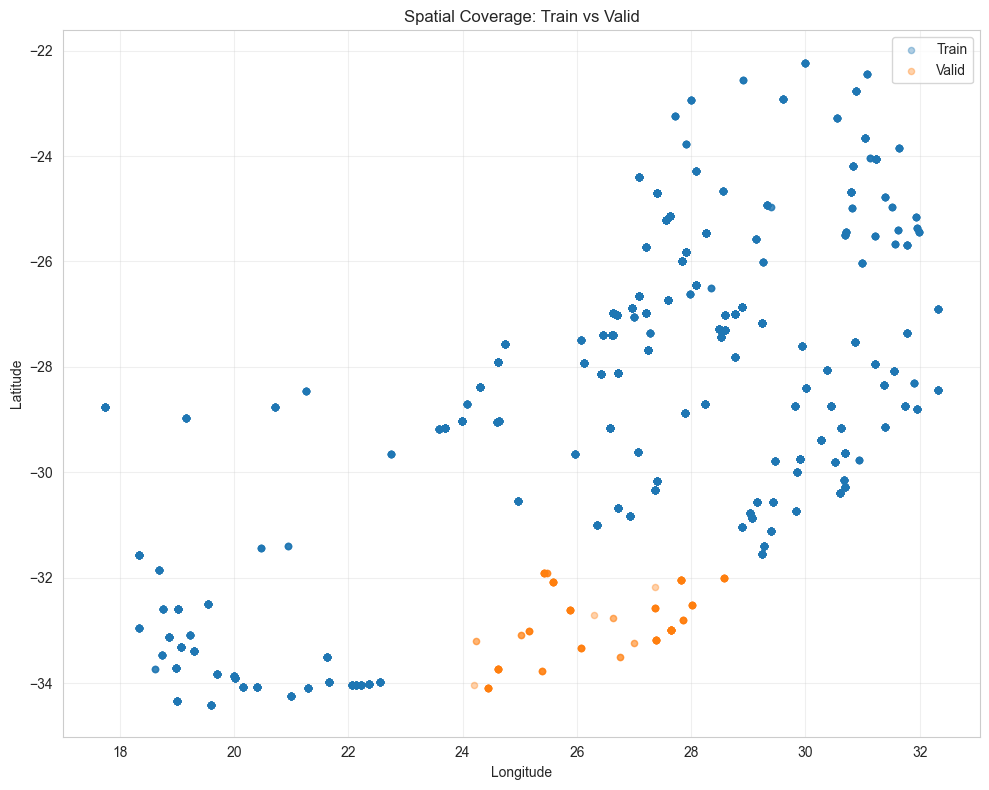

In [5]:
print("\n" + "=" * 70)
print("TRAIN vs VALID COMPARISON (Latitude, Longitude, Sample Date)")
print("=" * 70 + "\n")

DATE_COL = "Sample Date"
LAT_COL = "Latitude"
LON_COL = "Longitude"

# Build comparable subsets
train_cmp = df[[LAT_COL, LON_COL, DATE_COL]].copy()
valid_cmp = df_validation[[LAT_COL, LON_COL, DATE_COL]].copy()

for _df in (train_cmp, valid_cmp):
    _df[DATE_COL] = pd.to_datetime(_df[DATE_COL], errors="coerce", dayfirst=True)

train_cmp = train_cmp.dropna(subset=[LAT_COL, LON_COL, DATE_COL])
valid_cmp = valid_cmp.dropna(subset=[LAT_COL, LON_COL, DATE_COL])

# Summary table
summary = pd.DataFrame({
    "dataset": ["train", "valid"],
    "rows": [len(train_cmp), len(valid_cmp)],
    "lat_min": [train_cmp[LAT_COL].min(), valid_cmp[LAT_COL].min()],
    "lat_max": [train_cmp[LAT_COL].max(), valid_cmp[LAT_COL].max()],
    "lat_mean": [train_cmp[LAT_COL].mean(), valid_cmp[LAT_COL].mean()],
    "lon_min": [train_cmp[LON_COL].min(), valid_cmp[LON_COL].min()],
    "lon_max": [train_cmp[LON_COL].max(), valid_cmp[LON_COL].max()],
    "lon_mean": [train_cmp[LON_COL].mean(), valid_cmp[LON_COL].mean()],
    "date_min": [train_cmp[DATE_COL].min().date(), valid_cmp[DATE_COL].min().date()],
    "date_max": [train_cmp[DATE_COL].max().date(), valid_cmp[DATE_COL].max().date()],
})
display(summary)

# 1) Latitude/Longitude distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(train_cmp[LAT_COL], fill=True, alpha=0.30, label="Train", ax=axes[0], color="tab:blue")
sns.kdeplot(valid_cmp[LAT_COL], fill=True, alpha=0.30, label="Valid", ax=axes[0], color="tab:orange")
axes[0].set_title("Latitude Distribution: Train vs Valid")
axes[0].set_xlabel("Latitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.kdeplot(train_cmp[LON_COL], fill=True, alpha=0.30, label="Train", ax=axes[1], color="tab:blue")
sns.kdeplot(valid_cmp[LON_COL], fill=True, alpha=0.30, label="Valid", ax=axes[1], color="tab:orange")
axes[1].set_title("Longitude Distribution: Train vs Valid")
axes[1].set_xlabel("Longitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Sample date trend comparison (monthly count)
train_month = train_cmp.set_index(DATE_COL).resample("ME").size()
valid_month = valid_cmp.set_index(DATE_COL).resample("ME").size()

plt.figure(figsize=(14, 5))
plt.plot(train_month.index, train_month.values, marker="o", label="Train", color="tab:blue")
plt.plot(valid_month.index, valid_month.values, marker="o", label="Valid", color="tab:orange")
plt.title("Monthly Sample Count: Train vs Valid")
plt.xlabel("Sample Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Spatial overlay
plt.figure(figsize=(10, 8))
plt.scatter(train_cmp[LON_COL], train_cmp[LAT_COL], s=20, alpha=0.35, label="Train", color="tab:blue")
plt.scatter(valid_cmp[LON_COL], valid_cmp[LAT_COL], s=20, alpha=0.35, label="Valid", color="tab:orange")
plt.title("Spatial Coverage: Train vs Valid")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()